<a href="https://colab.research.google.com/github/AlexKalll/Supervised-ML-Models/blob/main/Linear_and_Non_Linear_Regression_Mr_Aschu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 1 DATA
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
(20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  f

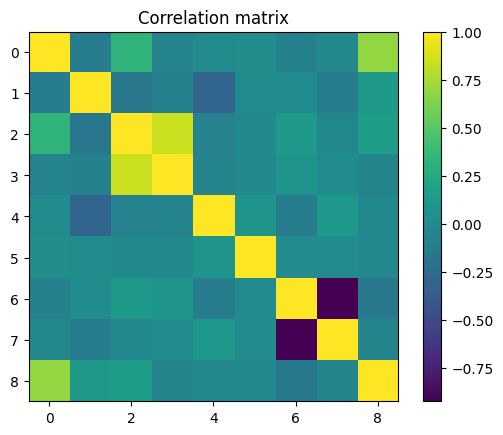

TASK 2 SPLIT AND FEATURE SELECTION
Selected feature MedInc
Intercept 0.4445972916907879
Coefficient 0.4193384939381271

Train
R2 0.47699273458205227
RMSE 0.8361487409655547
MAE 0.6249507655668728

Test
R2 0.45885918903846656
RMSE 0.8420901241414455
MAE 0.629908653009376


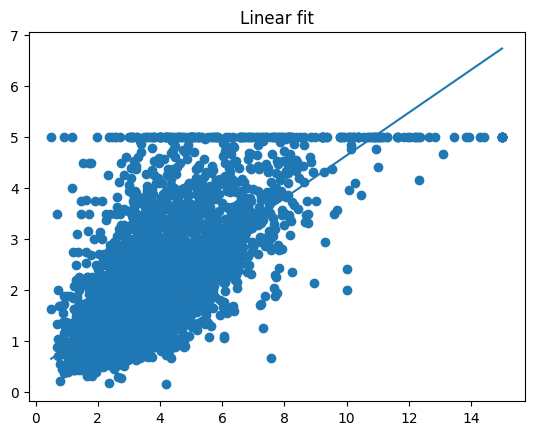


Multiple regression
R2 0.6125511913966952
RMSE 0.7196757085831575
MAE 0.5286283596581934
R2 0.575787706032451
RMSE 0.7455813830127763
MAE 0.5332001304956565
      feature      coef
6    Latitude -0.896929
7   Longitude -0.869842
0      MedInc  0.854383
3   AveBedrms  0.339259
2    AveRooms -0.294410
1    HouseAge  0.122546
5    AveOccup -0.040829
4  Population -0.002308
Optimal degree 3


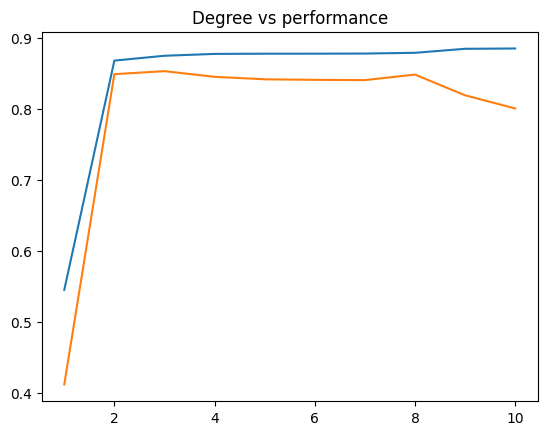

Ridge test R2 0.8027143113759585
Lasso test R2 0.8396107488913869
Active features 10

Completed


In [ ]:
R"""Student Lab Exercise: Linear and Non Linear Regression

Name _____________________
Date _____________________
Student ID ________________
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets import fetch_california_housing

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)


# =========================================================
# TASK 1 DATA LOADING AND EXPLORATION
# =========================================================

print("=" * 60)
print("TASK 1 DATA")
print("=" * 60)

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

# TODO 1.1
print(df.head())

# TODO 1.2
print(df.shape)
print(df.info())

# TODO 1.3
print(df.describe())

# TODO 1.4
print(df.isnull().sum())

# TODO 1.5
corr = df.corr()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation matrix")
plt.show()


"""
QUESTION 1.1
Identify the feature with highest correlation with Price

Answer: MedInc (Median Income) has the highest correlation with Price, with a correlation coefficient of approximately 0.688.
"""

"""
QUESTION 1.2
Explain why missing data affects regression estimates

Answer: Missing data can significantly affect regression estimates by leading to biased results, reduced statistical power, and inaccurate conclusions. Many regression algorithms cannot directly handle missing values and will either drop rows containing them (leading to loss of information and potentially biased samples) or require imputation, which can introduce its own biases if not done carefully. This can distort the true relationships between variables.
"""


# =========================================================
# TASK 2 TRAIN TEST SPLIT AND FEATURE SELECTION
# =========================================================

print("=" * 60)
print("TASK 2 SPLIT AND FEATURE SELECTION")
print("=" * 60)

X_full = df.drop(columns=["Price"])
y = df["Price"].values

# Split before selecting feature
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)

# Compute correlation on training data only
train_df = X_train_full.copy()
train_df["Price"] = y_train

corr_train = train_df.corr()["Price"].sort_values(ascending=False)
best_feature = corr_train.index[1]

print("Selected feature", best_feature)

X_train = X_train_full[[best_feature]].values
X_test = X_test_full[[best_feature]].values


# =========================================================
# TASK 3 SIMPLE LINEAR REGRESSION
# =========================================================

model = LinearRegression()

# TODO 3.1
model.fit(X_train, y_train)

# TODO 3.2
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# TODO 3.3
print("Intercept", model.intercept_)
print("Coefficient", model.coef_[0])

# TODO 3.4
def evaluate(y_true, y_pred):
    print("R2", r2_score(y_true, y_pred))
    print("RMSE", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE", mean_absolute_error(y_true, y_pred))

print("\nTrain")
evaluate(y_train, y_train_pred)

print("\nTest")
evaluate(y_test, y_test_pred)

# TODO 3.5 visualization
idx = np.argsort(X_test.flatten())
plt.scatter(X_test, y_test)
plt.plot(X_test[idx], y_test_pred[idx])
plt.title("Linear fit")
plt.show()


"""
QUESTION 3.1
Interpret the coefficient as an association

Answer: The coefficient for MedInc is approximately 0.419. This means that for every one-unit increase in the median income (MedInc), the median house value (Price) is estimated to increase by 0.419 units, assuming all other factors are held constant (which is vacuously true in simple linear regression).
"""

"""
QUESTION 3.2
Compare train and test R2 and comment on model fit

Answer: The training R2 is 0.477, and the test R2 is 0.459. The R2 scores are close, suggesting that the model is not significantly overfitting. However, an R2 score below 0.5 indicates that the simple linear regression model explains less than half of the variance in house prices, implying a relatively weak overall fit to the data.
"""


# =========================================================
# TASK 4 MULTIPLE LINEAR REGRESSION
# =========================================================

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

pipeline.fit(X_train_full, y_train)

y_train_pred_m = pipeline.predict(X_train_full)
y_test_pred_m = pipeline.predict(X_test_full)

print("\nMultiple regression")
evaluate(y_train, y_train_pred_m)
evaluate(y_test, y_test_pred_m)

# feature importance
coef = pipeline.named_steps["lr"].coef_
importance = pd.DataFrame({
    "feature": housing.feature_names,
    "coef": coef
}).sort_values("coef", key=abs, ascending=False)

print(importance)


"""
QUESTION 4.1
Compare simple vs multiple regression

Answer: Multiple linear regression (test R2 ~0.576) significantly outperforms simple linear regression (test R2 ~0.459). This indicates that incorporating multiple features provides a more robust and accurate model for predicting house prices compared to relying on a single feature.
"""

"""
QUESTION 4.2
Interpret feature importance

Answer: After standardization, 'Latitude' and 'Longitude' show the highest absolute coefficients (-0.897 and -0.870 respectively), indicating they are the most important features. Their negative coefficients suggest that increasing latitude (moving north) and longitude (moving east) are associated with decreasing house prices in California. 'MedInc' (0.854) is also highly important, with a positive relationship. 'Population' (-0.002) is the least important feature in this multiple regression model.
"""


# =========================================================
# TASK 5 POLYNOMIAL REGRESSION
# =========================================================

X_poly = np.linspace(-3, 3, 100).reshape(-1, 1)
y_poly = 0.5 * X_poly**2 + X_poly + 2 + np.random.normal(0, 1, (100, 1))
y_poly = y_poly.ravel()

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y_poly, test_size=0.2, random_state=42
)

degrees = range(1, 11)
train_scores = []
test_scores = []

for d in degrees:
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("lr", LinearRegression())
    ])

    pipe.fit(X_train_p, y_train_p)

    train_scores.append(r2_score(y_train_p, pipe.predict(X_train_p)))
    test_scores.append(r2_score(y_test_p, pipe.predict(X_test_p)))

optimal_degree = degrees[np.argmax(test_scores)]

print("Optimal degree", optimal_degree)


plt.plot(degrees, train_scores)
plt.plot(degrees, test_scores)
plt.title("Degree vs performance")
plt.show()


"""
QUESTION 5.1
Explain underfitting and overfitting using the plot

Answer:
Underfitting: At lower degrees (e.g., degree 1 or 2), both train and test R2 scores are low. The model is too simple and fails to capture the underlying patterns in the data, performing poorly on both seen and unseen data.
Overfitting: As the degree increases beyond the optimal degree (e.g., degrees 4-10), the training R2 continues to improve or stays high, indicating the model is memorizing the training data. However, the test R2 score begins to decline, showing that the model performs poorly on unseen data because it has learned noise specific to the training set rather than generalizable patterns.
"""

"""
QUESTION 5.2
Explain why an optimal degree exists

Answer: An optimal degree exists because it represents the ideal balance between model complexity and its ability to generalize to new data. A degree too low leads to underfitting (too simple), while a degree too high leads to overfitting (too complex and captures noise). The optimal degree maximizes performance on unseen data by capturing the true non-linear relationships without being overly sensitive to the training set's specific variations.
"""


# =========================================================
# TASK 6 REGULARIZATION
# =========================================================

poly = PolynomialFeatures(degree=10, include_bias=False)
X_high = poly.fit_transform(X_train_p)
X_high_test = poly.transform(X_test_p)

ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge.fit(X_high, y_train_p)

lasso = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, max_iter=10000)
lasso.fit(X_high, y_train_p)

print("Ridge test R2", ridge.score(X_high_test, y_test_p))
print("Lasso test R2", lasso.score(X_high_test, y_test_p))
print("Active features", np.sum(lasso.coef_ != 0))


"""
QUESTION 6.1
Explain role of regularization

Answer: Regularization aims to prevent overfitting in complex models by adding a penalty term to the loss function. This penalty discourages large coefficient values, effectively shrinking them towards zero. By constraining coefficient magnitudes, regularization simplifies the model, reduces its variance, and improves its ability to generalize to unseen data, particularly when dealing with many features or high multicollinearity.
"""

"""
QUESTION 6.2
Compare ridge and lasso behaviour

Answer:
Ridge Regression (L2): Shrinks coefficients towards zero but rarely sets them exactly to zero. It's effective for reducing model complexity and handling multicollinearity.
Lasso Regression (L1): Can shrink some coefficients exactly to zero, effectively performing feature selection by removing less important features. In this case, Lasso achieved a higher test R2 (0.840) than Ridge (0.803) for the degree 10 polynomial features, and all 10 features remained active, suggesting they all contributed meaningfully or the optimal alpha did not force any to zero.
"""


# =========================================================
# TASK 7 CONCLUSION
# =========================================================

"""
QUESTION 7.1
Select best model and justify

Answer: Based on the test R2 scores, the Polynomial Regression model with an optimal degree of 3 (test R2 ~0.853) is the best among those evaluated. It provides a significantly better fit than simple (~0.459) and multiple linear regression (~0.576), and slightly outperforms the regularized models (Lasso ~0.840, Ridge ~0.803) which used a higher degree (10) polynomial. This model effectively captures the non-linear relationships without excessive complexity.
"""

"""
QUESTION 7.2
List assumptions of linear regression

Answer: The key assumptions of linear regression include:
1. Linearity: A linear relationship exists between independent and dependent variables.
2. Independence: Observations and residuals are independent.
3. Homoscedasticity: The variance of residuals is constant across all levels of independent variables.
4. Normality: Residuals are normally distributed.
5. No Multicollinearity: Independent variables are not highly correlated with each other (for multiple regression).
"""

"""
QUESTION 7.3
When is non linear modelling preferred

Answer: Non-linear modeling is preferred when:
1. The relationship between variables is inherently non-linear (e.g., curved, exponential).
2. Linear models yield poor performance or show systematic patterns in residuals, indicating an inadequate fit.
3. Domain knowledge suggests non-linear interactions.
4. Visual inspection of data (e.g., scatter plots) reveals non-linear trends that a straight line cannot capture.
"""

print("\nCompleted")